In [2]:
import oqupy
import oqupy.operators as op
import numpy as np
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
import matplotlib.pyplot as plt


from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

alpha=0.1

Rho_0=oqupy.operators.spin_dm('mixed')

# spectral density (without cutoff)
def j(w):
    return 2*alpha*w


In [ ]:
# serialization of process tensor (optional)
import dill

# processtensor_simplemodel
file_name1='results/processtensors/processtensor_dt=0.2_ps=-7.0_tcut=50'
with open(file_name1,'rb') as f:
    process_tensor_var=dill.load(f)

# processtensor_simplemodel
file_name2='results/processtensors/processtensorCF_dt=0.2_ps=-8.0_tcut=50'
with open(file_name2,'rb') as f:
    process_tensor_varcf=dill.load(f)

with open('results/zero_control_0.2ps_8/100ps/optimization_simplemodel_100ps', 'rb') as f:
    opt_dict = dill.load(f)
    opt_control = opt_dict['result'].x

omega_cutoff = 1
temperature = 0.131

epsrel=10**(-8)
dt=0.2
tcut=50
u=0.01


--> Compute dynamics:
100.0% 5000 of 5000 [########################################] 00:07:22
Elapsed time: 442.1s
--> Compute dynamics:
  8.4%  420 of 5000 [###-------------------------------------] 00:07:32

KeyboardInterrupt: 

  8.4%  420 of 5000 [###-------------------------------------] 00:07:33

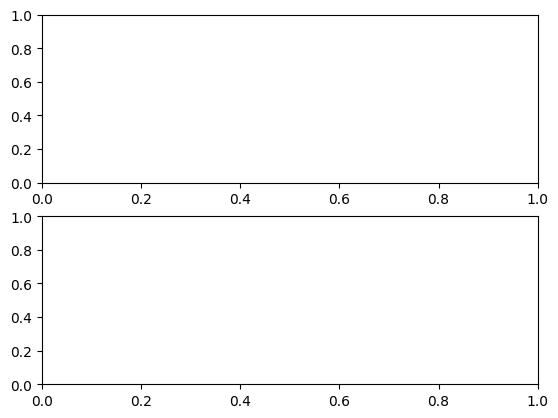

  8.4%  420 of 5000 [###-------------------------------------] 00:08:34

In [9]:
t_prots=1000
delta_t = interp1d(np.linspace(0,t_prots,len(opt_control)),opt_control)
def hamiltonian_t(t):
    return delta_t(t)*oqupy.operators.sigma("x")/2
u=0.01

for t_prot in [1000]:

   fig,axs=plt.subplots(2)

   num_steps=int(t_prot/dt)

   system = oqupy.TimeDependentSystem(hamiltonian_t)

   # compute dynamics

   dynamics=oqupy.compute_dynamics(
   process_tensor=process_tensor_var,        
   system=system,
   initial_state=Rho_0,
   start_time=0,
   num_steps=num_steps)
   t, s_x = dynamics.expectations(op.sigma('x'), real=True)

   # compute heats

   dynamicscf = oqupy.compute_dynamics(
   process_tensor=process_tensor_varcf,        
   system=system,
   initial_state=Rho_0,
   start_time=0,
   num_steps=num_steps)

   heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

   axs[0].plot(t,heats,label=t_prot)
   axs[0].set_xlabel(r'$t$')
   axs[0].set_ylabel(r'$\langle Q \rangle$')
   axs[1].plot(t,s_x)
   axs[1].set_xlabel(r'$t$')
   axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')
   plt.legend()
   plt.show()
